### `Instagram Influencer Performance Prediction Using Machine Learning Models`

`Description:`

* In the second part of the project, I used the cleaned and preprocessed Instagram influencers dataset to build machine learning models for prediction. The objective was to predict influencer performance metrics such as influence score and engagement rate based on historical engagement data and audience-related features.
  
* Various machine learning algorithms were applied to learn patterns from influencer attributes including followers count, average likes, number of posts, recent engagement rate, and country information. This phase focused on feature selection, model training, evaluation, and comparison to identify the best-performing model.

* The models were evaluated using appropriate performance metrics, and their results were compared to select the most accurate and reliable model. This predictive analysis helps brands and marketers estimate influencer impact and make informed decisions for influencer collaborations.

## 1. Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## 2. Load the dataset

In [2]:
data = pd.read_csv('top_insta_infl_cleaned_data.csv')

In [3]:
data.head()

,rank,username,influence_score,influence_category,posts,followers,avg_likes,engagement_rate,new_post_avg_like,total_likes,country,joining_month_name,joining_year,like_follower_ratio,post_follower_ratio
0,1,instagram,50,High,8310,698000000,327000,0.05,327000,2720000000,United States,February,2012,3.896848,0.000012
1,2,cristiano,61,High,4000,670000000,8700000,1.30,6500000,34800000000,Portugal,May,2012,51.940299,0.000006
2,3,leomessi,47,High,1450,511000000,6800000,1.33,4400000,9860000000,Spain,June,2013,19.295499,0.000003
3,4,selenagomez,40,Medium,2150,415000000,6200000,1.49,3300000,13330000000,United States,July,2013,32.120482,0.000005
4,5,kyliejenner,42,Medium,7360,391000000,8300000,2.12,2400000,61090000000,United States,November,2011,156.240409,0.000019


## 3. Feature Selection

In [4]:
data.columns

Index(['rank', 'username', 'influence_score', 'influence_category', 'posts',
       'followers', 'avg_likes', 'engagement_rate', 'new_post_avg_like',
       'total_likes', 'country', 'joining_month_name', 'joining_year',
       'like_follower_ratio', 'post_follower_ratio'],
      dtype='object')

In [5]:
# Define feature columns and target variable
X = data[['followers', 'avg_likes', 'engagement_rate', 'new_post_avg_like', 'like_follower_ratio', 'post_follower_ratio']]
y = data['influence_score']

## 4. Train-test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=52)

## 5.  Standardize features

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Model Apply

In [8]:
# Linear Regression Model
rf = RandomForestRegressor(n_estimators=30)
rf.fit(X_train, y_train)
rf.score(X_test, y_test)*100 , rf.score(X_train, y_train)*100

(96.31114313646171, 96.95477953322063)

In [9]:
# for i in range(1,30):
#     rf = RandomForestRegressor(n_estimators=6)
#     rf.fit(X_train, y_train)
#     print(i,rf.score(X_test, y_test)*100 , rf.score(X_train, y_train)*100)

## 7. Model Predictions and evaluation

In [10]:
y_pred = rf.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 172.373
R^2 Score: -0.3074408373786408


In [11]:
# Display actual vs predicted values for the first 10 samples
comparison = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': y_pred.flatten()})
comparison.head(10)

,Actual,Predicted
0,7,6.066667
1,18,6.100000
2,9,6.066667
3,6,6.066667
4,7,3.266667
5,14,6.066667
6,4,6.066667
7,4,3.266667
8,5,3.266667
9,8,3.266667


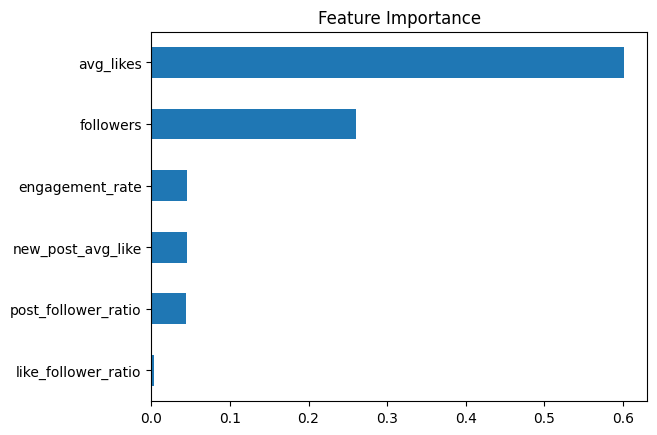

In [12]:
# Display feature importances
feature_importances = pd.Series(rf.feature_importances_,index=X.columns)
feature_importances.sort_values().plot(kind='barh',title='Feature Importance')
plt.show()
